# Zonal Statistics Test

This notebook shows plots to test functions in Geocube and exact extract. These results show similar values and work as intended.

#### 1. Import the required functions

In [ ]:
# More inports than nessasary...
import os
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt


# packages for getting zonal stats
mwb_flow_dir = r'C:\Users\CND905\Downloaded_Programs\pydlem'
os.chdir(mwb_flow_dir)

import GRIDtools as gt
from prep.metdata import get_gridmet_for_polygons
from prep.metdata import get_gridmet_for_polygons_with_geocube

Initializing pydlem.prep module.


#### 2. Set Up Test
 First, we get a polygon for the Soda Butte watershed since it will be used in other examples in the pydlem project. 

,req_idx,catchmentID,geometry,Area_sqKm,name,direction,upstream,gnis_name,comid,reachcode,intersection_point
0,0,NaN,"POLYGON ((-110.00979 44.97979, -110.00979 44.9...",80.116374,Soda Butte,up,True,Soda Butte Creek,2962790,10070001001206,"[-110.00253513072141, 45.0029964223079]"


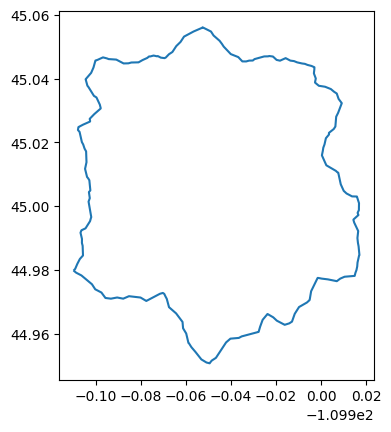

In [2]:
# Create geopandas.GeoDataFrame of some points we want to delineate upstream catchments for
pour_pnt = gpd.GeoDataFrame(
    {
        "name": ["Soda Butte"],
    },
    geometry=[Point(-110.0018722, 45.00283056)],
    crs=4326
)

watershed_gdf = gt.delineate_watershed(pour_pnt)

watershed_gdf.boundary.plot()
watershed_gdf

Next, we get meteorologic data using the get_gridmet_for_polygons() function which uses the xvec and exact extract packages.

In [3]:
watershed_gdf["catchmentID"] = '06187915' 

met_data = get_gridmet_for_polygons(in_geom=watershed_gdf, gdf_index_col="catchmentID", start='2016-10-01', end='2025-01-01') # added a day to account for day added by timezone in q_data
met_data

c:\Users\CND905\.conda\envs\pydlem\lib\site-packages\exactextract\exact_extract.py:330: RuntimeWarning: Spatial reference system of input features does not exactly match raster.
  warnings.warn(
c:\Users\CND905\.conda\envs\pydlem\lib\site-packages\exactextract\exact_extract.py:330: RuntimeWarning: Spatial reference system of input features does not exactly match raster.
  warnings.warn(


<xarray.Dataset> Size: 193kB
Dimensions:        (location: 1, time: 3015)
Coordinates:
    lat            (location) float64 8B 45.0
    lon            (location) float64 8B -109.9
    elev           (location) float64 8B 2.912e+03
    area           (location) float64 8B 80.12
  * location       (location) <U8 32B '06187915'
  * time           (time) datetime64[ns] 24kB 2016-10-01 ... 2025-01-01
Data variables:
    max_temp       (time, location) float64 24kB 286.7 281.6 ... 264.3 263.6
    min_temp       (time, location) float64 24kB 274.5 274.3 ... 258.3 259.0
    precip_volume  (time, location) float64 24kB 4.071e+05 ... 3.844e+05
    solrad         (time, location) float64 24kB 155.0 139.1 ... 61.94 75.28
    wind_dir       (time, location) float64 24kB 198.1 165.9 ... 261.5 230.8
    wind_vel       (time, location) float64 24kB 4.438 4.308 3.985 ... 3.515 5.7
    vpd            (time, location) float64 24kB 0.5392 0.3069 ... 0.08077
Attributes:
    featureType:  timeSeries

Then we get meteorologic data using the get_gridmet_for_polygons_with_geocube() which uses the geocube package. 

In [4]:
watershed_gdf["catchmentID"] = 6187915
grid_data = get_gridmet_for_polygons_with_geocube(in_geom=watershed_gdf, gdf_index_col="catchmentID", start='2016-10-01', end='2025-01-01')
grid_data

Parameters: 100%|██████████| 7/7 [02:43<00:00, 23.40s/it]


<xarray.Dataset> Size: 193kB
Dimensions:   (time: 3015, location: 1)
Coordinates:
  * time      (time) datetime64[ns] 24kB 2016-10-01 2016-10-02 ... 2025-01-01
  * location  (location) int64 8B 6187915
    lat       (location) float64 8B 45.0
    lon       (location) float64 8B -109.9
    elev      (location) float64 8B 2.912e+03
    area      (location) float64 8B 80.12
Data variables:
    max_temp  (time, location) float64 24kB 286.4 281.2 277.0 ... 263.9 263.3
    min_temp  (time, location) float64 24kB 274.4 274.1 270.8 ... 257.9 258.6
    solrad    (time, location) float64 24kB 154.8 139.2 137.3 ... 61.88 75.42
    wind_dir  (time, location) float64 24kB 196.8 166.5 243.8 ... 260.8 229.8
    wind_vel  (time, location) float64 24kB 4.454 4.308 3.992 ... 3.5 5.654
    vpd       (time, location) float64 24kB 0.5308 0.2977 ... 0.06769 0.07615
    volume    (time, location) float64 24kB 4.276e+05 6.888e+05 ... 3.989e+05
Attributes:
    featureType:  timeSeries

#### Plot Results

We test the functions a couple ways. This first comparison of results tells us if the xvec function returns the same values as the get_gridmet_for_polygons_with_geocube() which actually uses a GRIDtools.grid_area_weighted_volume() function. This is because the precip is summed over area. 

So these results tell us that xvec works correctly when summing data over an area and that the area calculations are also correct. 

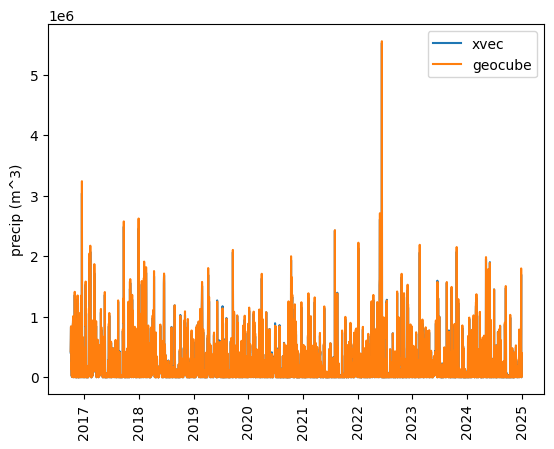

Text(0.5, 0, 'geocube (precip_volume)')

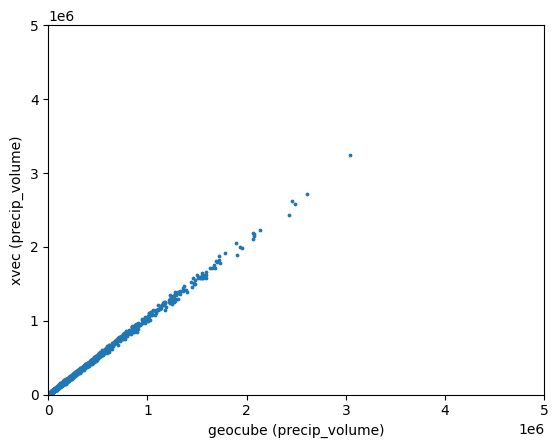

In [5]:
x = met_data['time'].values
y1 = met_data['precip_volume'].values[:,0]
y2 = grid_data['volume'].values[:,0]

plt.xticks(rotation=90)
plt.plot(x, y1)
plt.plot(x, y2)
plt.ylabel("precip (m^3)")
classes = ['xvec', 'geocube']
plt.legend(labels=classes)
plt.show()

plt.scatter(y1, y2, s=3)
plt.xlim(0, 5000000)
plt.ylim(0, 5000000)
plt.ylabel("xvec (precip_volume)")
plt.xlabel("geocube (precip_volume)")

We can also see that the xvec function and geocube function that were used for getting the zonal stats of temperature are similar. Temperature was used since a mean is taken over the polygon area. 

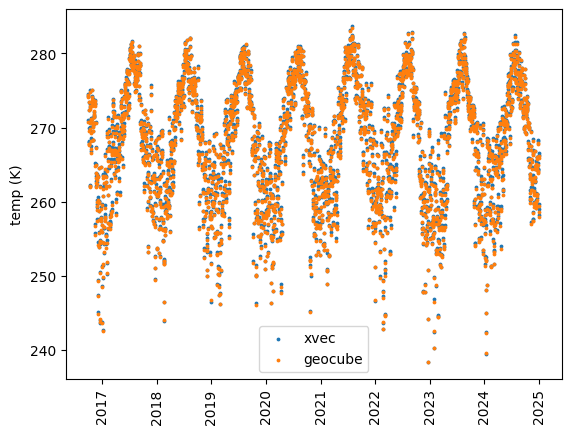

Text(0.5, 0, 'geocube (min temp)')

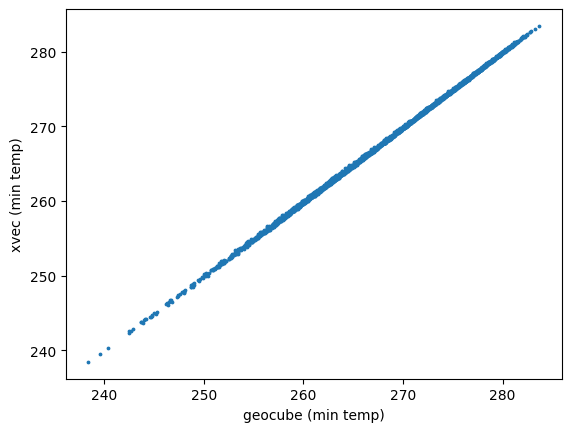

In [6]:
x = met_data['time'].values
y1 = met_data['min_temp'].values[:,0]
y2 = grid_data['min_temp'].values[:,0]

plt.xticks(rotation=90)
plt.scatter(x, y1, s=3)
plt.scatter(x, y2, s=3)
plt.ylabel("temp (K)")
classes = ['xvec', 'geocube']
plt.legend(labels=classes)
plt.show()

plt.scatter(y1, y2, s=3)
plt.ylabel("xvec (min temp)")
plt.xlabel("geocube (min temp)")


xvec seems to work well so we will use it since it is only one package. 